# Simulación Variables macroscópicas

In [1]:
using LinearAlgebra
using SpecialFunctions
using Distributions
using Random
using Plots
using LaTeXStrings
using StaticArrays

In [2]:
function K(θ::Float64)
    return @SMatrix [exp(im * θ)  0.0+0.0im; 
                     0.0+0.0im    exp(-im * θ)]
end

function N(x::Float64)
    return @SMatrix [1.0 - im*x   im*x; 
                     -im*x        1.0 + im*x]
end


function A(t::Float64)
    return @SMatrix [cosh(t)  sinh(t);
                     sinh(t)  cosh(t)]
end

A (generic function with 1 method)

In [99]:
function ensemble(n_matrices::Int, n_samples::Int, component::Tuple{Int,Int}, η::Float64, Φ::Float64)
    # Preallocate output array
    samples = Vector{ComplexF64}(undef, n_samples)
    
    # standard deviations
    σ_ν = sqrt(η / n_matrices) 
    σ_ϕ = sqrt(Φ / n_matrices)

    row, col = component[1], component[2]
    
    for i in 1:n_samples
        # Strictly Static Identity Matrix
        M = @SMatrix [1.0+0.0im 0.0+0.0im; 
                      0.0+0.0im 1.0+0.0im] 
        θ_total = 0.0              
        for _ in 1:n_matrices
            x = rand(Normal(0, σ_ν))
            θ = rand(Normal(2*π, σ_ϕ))
            θ_total += θ
            M = M * (K(θ) * N(x)) 
        end
        ν_rand_n=rand(Normal(0, σ_ν))
        M = K(-θ_total) * N(ν_rand_n) * M 
        samples[i] = M[row, col]
    end
    
    return samples
end

ensemble (generic function with 1 method)

In [89]:
function gen_avg(σ_ν, σ_ϕ, N)
    τ=1+σ_ν^2/2+(1-σ_ν^2/2)exp(-σ_ϕ^2/2)
    λ_p=τ/2+0.5*√(τ^2-4exp(-σ_ϕ^2/2))
    λ_m=τ/2-0.5*√(τ^2-4exp(-σ_ϕ^2/2))
    return 0.5*((λ_p^N-λ_m^N)/(λ_p-λ_m) * (1+σ_ν^2/2) - exp(-σ_ϕ^2/2) * (λ_p^(N-1)-λ_m^(N-1))/(λ_p-λ_m) +1)
end

gen_avg (generic function with 1 method)

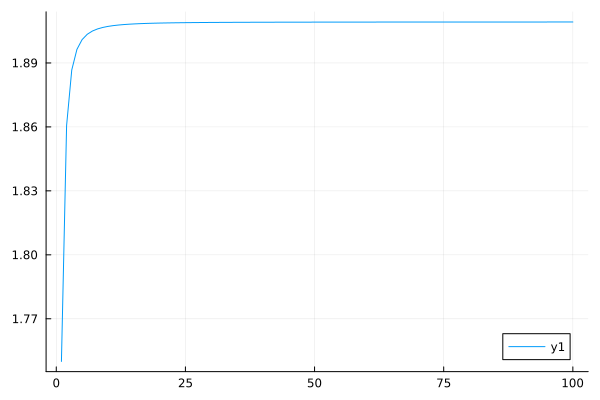

In [90]:
T_inv(N)=gen_avg(sqrt(3/N), sqrt(2/N),N)
gr()
plot(range(1, 100, length=100), T_inv)
#ylims!(1,3)

In [91]:
function expected_T_inv(η, Φ, N_vals)
    sq_term = sqrt(4*η*Φ + Φ^2)
    val = 0.5 * (1 + exp(-Φ/4) * (cosh(sq_term/4) + ((2*η + Φ) / sq_term) * sinh(sq_term/4)))
    return fill(val, length(N_vals))
end

expected_T_inv (generic function with 1 method)

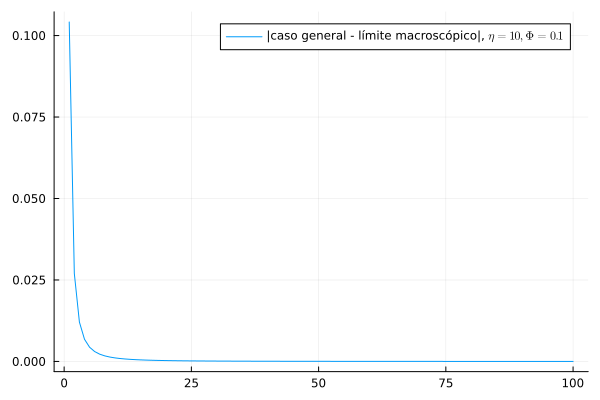

In [92]:
function dif(eta, Phi, N)
    return abs(gen_avg(sqrt(eta/N),sqrt(Phi/N),N)-expected_T_inv(eta,Phi,1)[1])
end
et=10
ph=0.1
y(N)=dif(et,ph,N)
gr()
plot(range(1, 100, length=100), y, label="|caso general - límite macroscópico|, \$η=$et, Φ=$ph\$")

In [100]:
η_p = 4.0
Φ_p = 0.1
N_valores = 2:2:240
n_samples = 10_000
# Run simulation
means = Vector{Float64}(undef, length(N_valores))
for (i, N_dis) in enumerate(N_valores)
    #println("Simulating N = $N_dis...") 
    M_11 = ensemble(N_dis, n_samples, (1, 1), η_p, Φ_p)
    means[i] = mean(abs2, M_11)
end

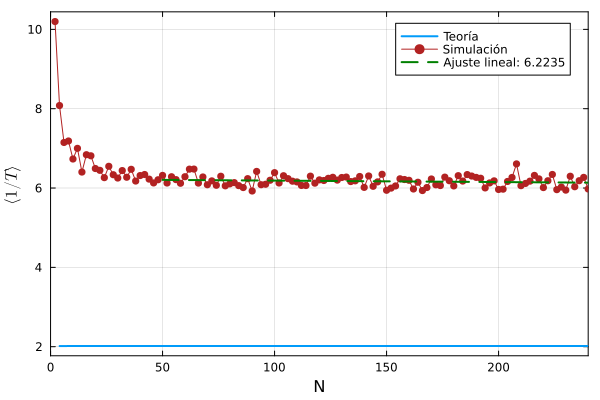

In [103]:
# Filter data for N >= 50
idx_filter = N_valores .>= 50
x_data = Float64.(N_valores[idx_filter])
y_data = means[idx_filter]

# Perform linear fit: y = a*x + b
A_matrix = [x_data ones(length(x_data))]
coeffs = A_matrix \ y_data
slope = coeffs[1]
intercept = coeffs[2]

# Calculate R² for goodness of fit
y_pred = slope .* x_data .+ intercept
#ss_res = sum((y_data .- y_pred).^2)
#ss_tot = sum((y_data .- mean(y_data)).^2)
#r_squared = 1 - ss_res / ss_tot

gr()
plot(N_vals, theory_line, label="Teoría", framestyle=:box, lw=2)
plot!(N_valores, means, marker=:circle, xlabel="N", ylabel=L"⟨1/T⟩", 
      label="Simulación", color=:firebrick, markerstrokewidth=0)
plot!(x_data, y_pred, label="Ajuste lineal: $(round(intercept,digits=4))", 
      lw=2, color=:green, linestyle=:dash)
xlims!(0, 240)

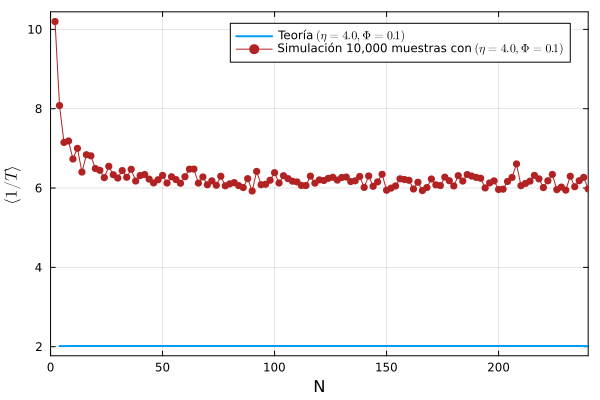

In [102]:
gr()
N_vals = range(0, 400, length=100)
# Calculate theoretical limit
theory_line(N) = gen_avg(sqrt(η_p/N), sqrt(Φ_p/N), N)
plot(N_vals, theory_line, label="Teoría \$(η=$η_p, Φ=$Φ_p)\$", framestyle=:box,lw=:2)
#hline!([1+η_p/4], label=L"y=1.5", color="purple")
plot!(N_valores, means, marker=:circle, xlabel="N", ylabel=L"⟨1/T⟩", label="Simulación 10,000 muestras con \$(η=$η_p, Φ=$Φ_p)\$",color=:firebrick, markerstrokewidth=0, legend=:topright)
xlims!(0,240)
#ylims!(3.5,25)
#savefig("macroscopic2.png")

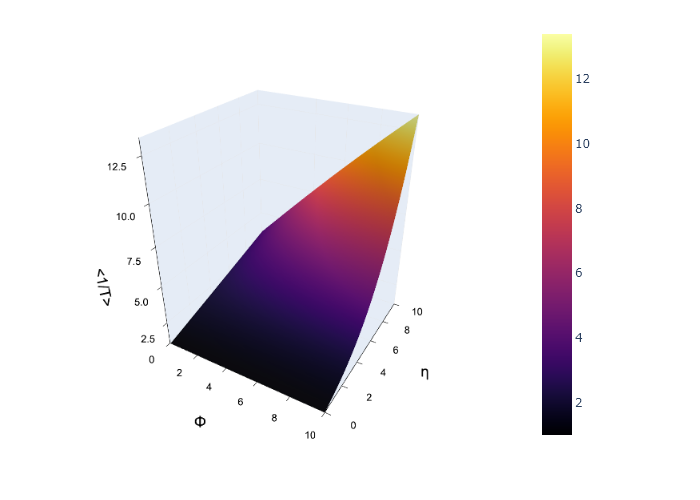

In [73]:
function z(Φ,η)
    return 0.5 * (1 + exp(-Φ/4) * (cosh(sqrt(4*η*Φ + Φ^2)/4) + ((2*η + Φ) / sqrt(4*η*Φ + Φ^2)) * sinh(sqrt(4*η*Φ + Φ^2)/4)))# parece que falta sumar una constante +c
end

plotlyjs() #imagen interactiva
Φ_vals = range(0.0, stop=10.0, length=200)
η_vals = range(0.0, stop=10.0, length=200)

# build Z as a matrix: rows -> η, cols -> Φ
Z = [ z(Φ, η) for η in η_vals, Φ in Φ_vals ]

surface(Φ_vals, η_vals, Z;
    xlabel="Φ", ylabel="η", zlabel="<1/T>")